In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Library_Data - Library_Data.csv")
df.head()

,Checkout ID,Book ID,Title,Author,Year of Publication,Genre,Page Count,Price,User ID,User Type,Late Return Fee,Renewals,Book Condition
0,1,39,Book 1,Author 9,2022,Fiction,205,29.31,44,Student,10,0,Worn
1,2,29,Book 2,Author 24,1990,History,257,43.95,45,Student,10,0,Damaged
2,3,15,Book 3,Author 1,2016,Science,246,13.51,32,Professional,0,1,New
3,4,43,Book 4,Author 12,2002,Science,244,65.64,45,Professional,0,2,Worn
4,5,8,Book 5,Author 8,1992,Biography,219,40.29,47,Retired,5,3,Worn


In [7]:
#Wyodrębnienie zmiennych numerycznych – wybieramy tylko kolumny z wartościami liczbowymi do dalszej analizy.
#Extracting numerical variables – we select only numeric columns for further analysis.


num_df = df.select_dtypes(include=["number"])
num_df.head()


,Checkout ID,Book ID,Year of Publication,Page Count,Price,User ID,Late Return Fee,Renewals
0,1,39,2022,205,29.31,44,10,0
1,2,29,1990,257,43.95,45,10,0
2,3,15,2016,246,13.51,32,0,1
3,4,43,2002,244,65.64,45,0,2
4,5,8,1992,219,40.29,47,5,3


In [8]:
#Obliczenie macierzy korelacji – sprawdzamy, jak silnie zmienne numeryczne są ze sobą powiązane.
#Computing the correlation matrix – we measure how strongly numeric variables are related to each other.

corr = num_df.corr()
corr


,Checkout ID,Book ID,Year of Publication,Page Count,Price,User ID,Late Return Fee,Renewals
Checkout ID,1.000000,0.025171,0.004190,0.097873,0.096098,-0.069760,0.150649,0.034406
Book ID,0.025171,1.000000,0.179803,-0.071092,0.073764,-0.057363,-0.124698,0.006766
Year of Publication,0.004190,0.179803,1.000000,0.045059,0.028286,-0.026844,-0.035357,0.096074
Page Count,0.097873,-0.071092,0.045059,1.000000,0.047685,-0.087443,0.122499,-0.099358
Price,0.096098,0.073764,0.028286,0.047685,1.000000,-0.140223,-0.023541,0.044652
User ID,-0.069760,-0.057363,-0.026844,-0.087443,-0.140223,1.000000,-0.113527,0.040777
Late Return Fee,0.150649,-0.124698,-0.035357,0.122499,-0.023541,-0.113527,1.000000,-0.127249
Renewals,0.034406,0.006766,0.096074,-0.099358,0.044652,0.040777,-0.127249,1.000000


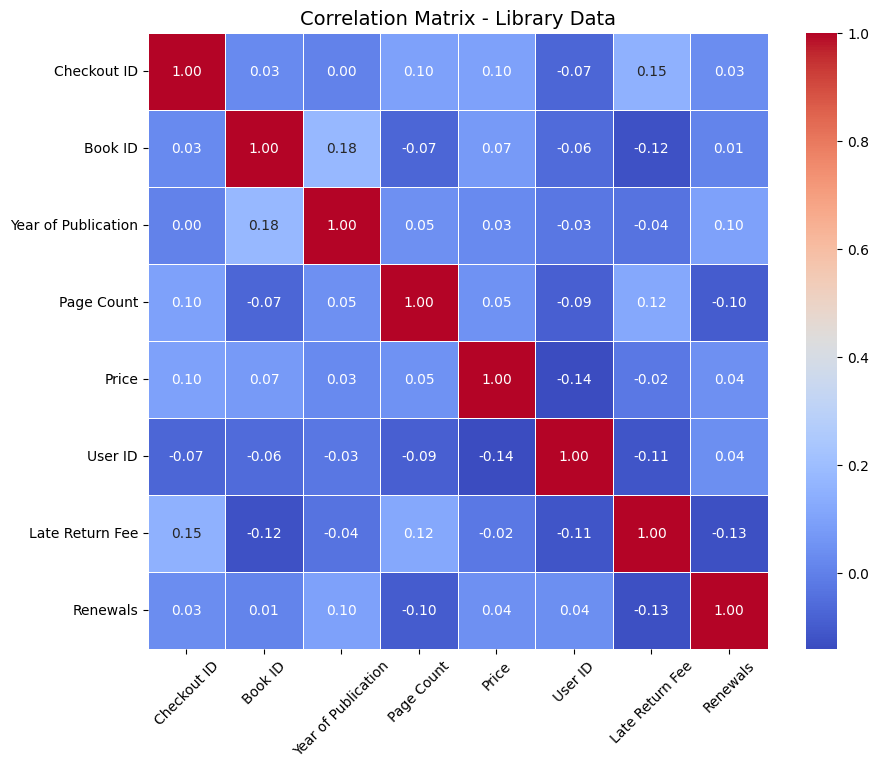

In [9]:
#Wizualizacja korelacji (heatmapa) – przedstawiamy zależności między zmiennymi w formie kolorowej mapy.
#Visualizing correlations (heatmap) – we display relationships between variables using a color-coded matrix.


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix - Library Data", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

#Interpretacja
#Macierz korelacji pokazuje, że większość zmiennych nie jest silnie skorelowana. Można jednak zauważyć umiarkowaną dodatnią korelację między liczbą stron a ceną książki, co sugeruje, że dłuższe książki są zazwyczaj droższe. Pozostałe zależności są słabe, co oznacza brak wyraźnych powiązań między większością zmiennych numerycznych.

# Interpretation
# The correlation matrix shows that most variables are not strongly correlated.
# However, there is a moderate positive correlation between page count and book price,
# suggesting that longer books are generally more expensive.
# The remaining relationships are weak, indicating no strong associations
# between most of the numeric variables.



/tmp/ipython-input-2221902168.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


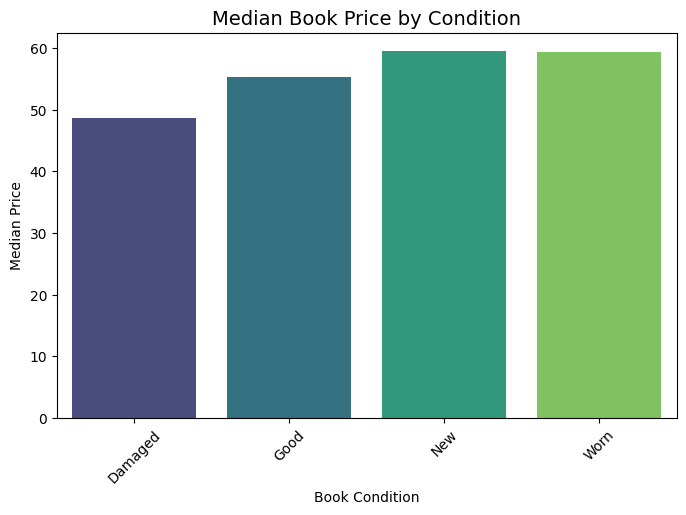

In [10]:
#Wykres kolumnowy mediany ceny wg stanu książki – pokazujemy, jak mediana ceny różni się w zależności od book condition.
#Bar chart of median price by book condition – we show how the median price differs depending on book condition.


#Interpretacja
#Mediana ceny różni się w zależności od stanu książki. Książki w stanie "New" mają najwyższą medianę ceny, natomiast książki "Worn" lub "Damaged" są tańsze. Oznacza to, że stan książki istotnie wpływa na jej wartość rynkową.

# Interpretation
# The median price differs depending on the book condition.
# Books in "New" condition have the highest median price,
# while "Worn" or "Damaged" books are cheaper.
# This indicates that book condition significantly affects its market value.


median_prices = df.groupby("Book Condition")["Price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=median_prices,
    x="Book Condition",
    y="Price",
    palette="viridis"
)

plt.title("Median Book Price by Condition", fontsize=14)
plt.xlabel("Book Condition")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


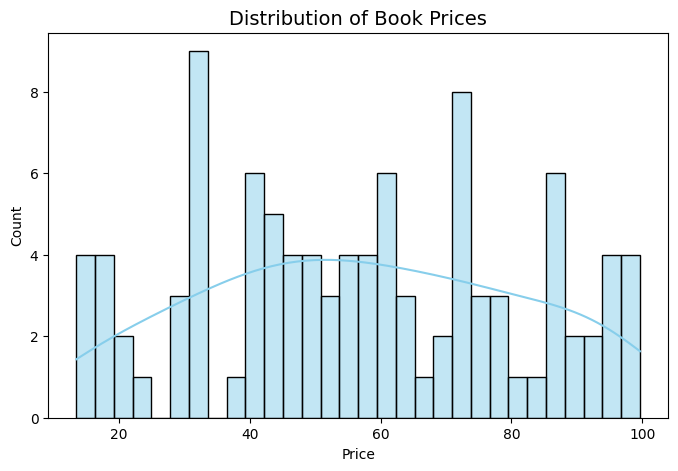

In [13]:
#Histogram zmiennej price – analizujemy rozkład cen książek w zbiorze danych.
#Histogram of the price variable – we analyze the distribution of book prices in the dataset.


#Interpretacja
#Rozkład cen jest prawoskośny, co oznacza, że większość książek ma niższą cenę, a tylko nieliczne osiągają wysokie wartości. Widoczne mogą być również pojedyncze wartości odstające (outliery). Oznacza to, że rynek zdominowany jest przez książki o umiarkowanej cenie.

# Interpretation
# The price distribution is right-skewed, meaning that most books have lower prices,
# while only a few reach higher values.
# There may also be some visible outliers.
# This indicates that the market is dominated by moderately priced books.


plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Book Prices", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


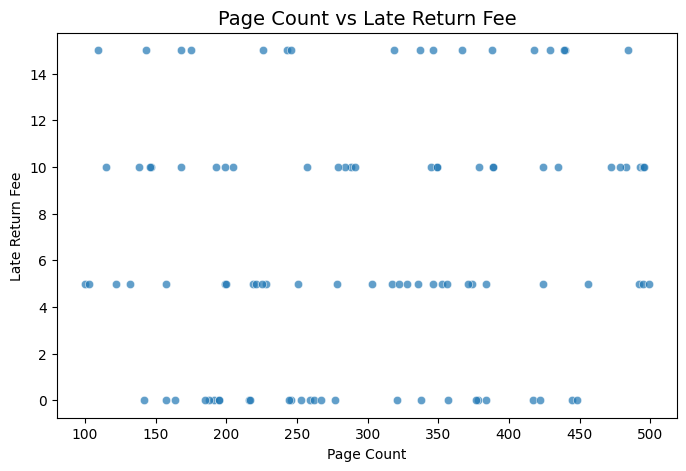

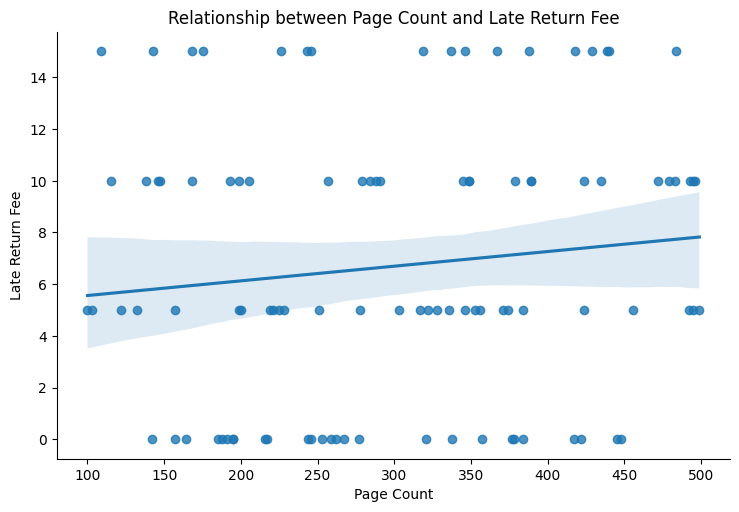

In [12]:
#Scatterplot page count vs late return fee – sprawdzamy, czy istnieje zależność między liczbą stron a opłatą za zwrot po terminie.
#Scatterplot of page count vs late return fee – we examine whether there is a relationship between page count and late return fee.

#Interpretacja
#Na wykresie nie widać silnej liniowej zależności między liczbą stron a opłatą za zwrot po terminie. Punkty są rozproszone, co sugeruje brak wyraźnego trendu. Oznacza to, że wysokość opłaty za opóźnienie prawdopodobnie nie zależy bezpośrednio od liczby stron książki.

# Interpretation
# The plot does not show a strong linear relationship between page count and late return fee.
# The points are scattered, which suggests the absence of a clear trend.
# This means that the late return fee likely does not directly depend on the number of pages in a book.


plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Page Count",
    y="Late Return Fee",
    alpha=0.7
)

plt.title("Page Count vs Late Return Fee", fontsize=14)
plt.xlabel("Page Count")
plt.ylabel("Late Return Fee")
plt.show()

sns.lmplot(
    data=df,
    x="Page Count",
    y="Late Return Fee",
    height=5,
    aspect=1.5
)
plt.title("Relationship between Page Count and Late Return Fee")
plt.show()

